In [1]:


from src.agents.nodes.sql_generate_query_node import generate_sql_node
from utils.sql_tools import WmsSqlTool
from langchain_community.tools.sql_database.tool import QuerySQLDatabaseTool, QuerySQLCheckerTool, InfoSQLDatabaseTool,ListSQLDatabaseTool
from langchain_google_genai import ChatGoogleGenerativeAI
from src.config import settings

_llm = None

def _getllm() -> ChatGoogleGenerativeAI:
    global _llm

    if _llm is None:
        _llm = ChatGoogleGenerativeAI(
            model=settings.GOOGLE_AI_MODEL,
            api_key=settings.GOOGLE_API_KEY,


        )
    return _llm
tools = WmsSqlTool(query_check_llm=_getllm())

query_tool = next(t for t in tools.get_sql_tools() if isinstance(t, QuerySQLDatabaseTool))
query_check = next(t for t in tools.get_sql_tools() if isinstance(t, QuerySQLCheckerTool))
list_tables = next(t for t in tools.get_sql_tools() if isinstance(t, ListSQLDatabaseTool))
list_info = next(t for t in tools.get_sql_tools() if isinstance(t, InfoSQLDatabaseTool))

res= list_info.invoke({"table_names": list_tables.invoke("")})


ImportError: cannot import name 'generate_sql_node' from 'src.agents.nodes.sql_generate_query_node' (/Users/rahul/Library/Mobile Documents/com~apple~CloudDocs/SCM_Agentic_Ai/WMS_Incident_Copilot/src/agents/nodes/sql_generate_query_node.py)

In [ ]:
res

In [ ]:
tool = tools.get_sql_tools()

next(t for t in tool if isinstance(t, QuerySQLDatabaseTool))

In [ ]:
from pprint import pprint
check_sql = "select * from inventory wher limit 10"
checked_sql = query_check.invoke({"query": check_sql})
pprint(checked_sql)


In [ ]:
from data.state import WMState
from agents.nodes.query_enrich_node import router_node

state = WMState(
    ticket_number= "INC12345",
    description= "how to slot sku003 and how much",
    user_id= "rahul"
)

router = router_node(state)

router


In [ ]:
from agents.graph.sql_subgraph import sql_graph
from domain.states.sql_subgraph_state.sql_graph_state import SQLGraphState
from dotenv import load_dotenv
load_dotenv()
state = SQLGraphState(

    description= "how many picks left?",
    domain="outbound"
)

router = sql_graph.invoke(state)

from rich.console import Console
from rich.markdown import Markdown
console = Console()

console.print(Markdown(router['final_response']))


In [1]:
from langgraph.graph import StateGraph, START, END
from src.data.state import WMState
from IPython.display import display, Image
from src.agents.nodes.query_enrich_node import router_node
from agents.graph.sql_subgraph import sql_graph
from src.agents.nodes.sql_result_node import return_result_node
from src.agents.edges.router_intent_edge import router_intent_edge
from langgraph.cache.memory import InMemoryCache
from agents.nodes.supervisor_node import SupervisorNode
from agents.nodes.inbound_agent_node import inbound_agent_node
from agents.nodes.outbound_agent_node import outbound_agent_node
from agents.nodes.inventory_agent_node import inventory_agent_node
from dotenv import load_dotenv
load_dotenv()
builder = StateGraph(WMState)
supervisor_node = (SupervisorNode())

builder.add_node("router_node", router_node)
builder.add_node("sql_query_subgraph", sql_graph)
builder.add_node("return_result_node", return_result_node)
builder.add_node("supervisor_node", supervisor_node)
builder.add_node("inbound_agent_node", inbound_agent_node)
builder.add_node("outbound_agent_node", outbound_agent_node)
builder.add_node("inventory_agent_node", inventory_agent_node)


builder.add_edge(START, "router_node")
builder.add_conditional_edges(
    "router_node",
    router_intent_edge,
    {
        "lookup":"sql_query_subgraph",
        "diagnose": "supervisor_node"
    }
)
builder.add_conditional_edges(
    "supervisor_node",
    lambda state: ["inbound_agent_node", "outbound_agent_node", "inventory_agent_node"],
    {
        "inbound_agent_node": "inbound_agent_node",
        "outbound_agent_node": "outbound_agent_node",
        "inventory_agent_node": "inventory_agent_node",
    }
)

# Agents → back to supervisor
builder.add_edge("inbound_agent_node", "supervisor_node")
builder.add_edge("outbound_agent_node", "supervisor_node")
builder.add_edge("inventory_agent_node", "supervisor_node")

# Supervisor can also go to result
builder.add_edge("return_result_node", END)

graph = builder.compile(cache=InMemoryCache())

display(Image(graph.get_graph().draw_mermaid_png()))


ModuleNotFoundError: No module named 'src.data.state'

In [ ]:
result = await graph.ainvoke(
    {
        "ticket_number": "INC12345",
        "description": "what all issues in inbound ?",
        "user_id": "rahul",
        "domain": "inventory",
    }
)

from rich.console import Console
from rich.markdown import Markdown

console = Console()

print(type(result))
print(result)

final_text = result.get("final_response") or str(result)
print("FINAL_TEXT:", repr(final_text))

console.print(Markdown(final_text))

In [ ]:


from langchain_core.messages import HumanMessage

from data.state import WMState
from models.model_loader import get_google_llm

get_google_llm().invoke([HumanMessage(content="Hello")]).content[0]["text"].strip()

In [ ]:


from agents.nodes.supervisor_node import SupervisorNode
from data.state import WMState

message = (
   "picking is low and uph is low but invenotry is high why and also inbound has no work"
)

state = WMState(
    ticket_number="INC12345",
    description=message,
    user_id="rahul",
)


node = SupervisorNode()
response = await node(state)
print(response)


In [ ]:
for data in response.goto:
    print(data)
    print("="*90)


In [ ]:
from agents.nodes.supervisor_node import SupervisorNode
from agents.nodes.inbound_agent_node import inbound_agent_node
from data.state import WMState, WorkerInput

AGENTS = {
    "inbound_agent": inbound_agent_node,
    # "outbound_agent": outbound_agent_node,
    # "inventory_agent": inventory_agent_node,
}

message = (
    "whats the over wms load"
)

state = WMState(
    ticket_number="INC12345",
    description=message,
    user_id="rahul",
)

supervisor = SupervisorNode()

# Run supervisor
cmd = await supervisor(state)
print("Supervisor returned:")
print(cmd)


In [ ]:
from agents.graph.sql_subgraph import sql_graph
from data.state import SQLGraphState
state2 = SQLGraphState(
    domain="outbound",
    description="how much left in picking outbound and what all skus"
)

res = sql_graph.invoke(state2)

res

In [ ]:
state2 = SQLGraphState(
    domain="outbound",
    description="how much sku do we need for picking"
)

res = sql_graph.invoke(state2)

res

In [ ]:
from models.model_loader import get_openai_fast_llm
from domain.states.supervisor.supervisor_subagent_task_state import SupervisorToSubAgentDeligationItem

llm = get_openai_fast_llm().with_structured_output(SupervisorToSubAgentDeligationItem)

response = llm.invoke([
    {"role": "system", "content": "You are a WMS diagnose agent elaborate issues in depth"},
    {"role": "user", "content": "whats my inbound issues"}
])

response

In [ ]:
for data in response.subagent_deligations:
    print(data.subagent_task)
    print("="*19)

In [ ]:
from agents.nodes.supervisor_node import SupervisorNode
from domain.states.supervisor.diagnose_graph_state import WMState

message = (
    "whats inbound staus"
)
state = WMState(
    ticket_number="INC12345",
    description=message,
)


node = SupervisorNode()
response = await node(state)
print(response)


# subagent_name= subagent_name,
#             worker_task=subagent_research_task,
#             task_id=str(task_id),
#             domain_name=domain,

In [ ]:
response.goto

In [ ]:
from langgraph.graph import StateGraph, START, END
from domain.states.supervisor.diagnose_graph_state import WMState
from IPython.display import display, Image
from src.agents.nodes.query_enrich_node import router_node
from agents.graph.sql_subgraph import sql_graph
from agents.edges.router_intent_edge import router_intent_edge
from agents.nodes.supervisor_node import WarehouseSupervisorNode
from agents.nodes.diagnose_result_node import diagnose_result_node
from agents.nodes.sql_lookup_subgraph_node import sql_query_subgraph_node
from dotenv import load_dotenv
load_dotenv()
builder = StateGraph(WMState)
supervisor_node = WarehouseSupervisorNode()

builder.add_node("router_node", router_node)
builder.add_node("sql_query_subgraph_node", sql_query_subgraph_node)

builder.add_node("supervisor_node", supervisor_node)
builder.add_node("diagnose_result_node", diagnose_result_node)

builder.add_edge(START, "router_node")

builder.add_conditional_edges(
    "router_node",
    router_intent_edge,
    {
        "lookup": "sql_query_subgraph_node",
        "diagnose": "supervisor_node",
    },
)

# lookup path ends here
builder.add_edge("sql_query_subgraph_node", END)

# diagnose_result_node is your explicit finish node
builder.add_edge("diagnose_result_node", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:

result = await graph.ainvoke(
    {
        "ticket_number":"INC12345",
        "description":"what status of inbound ?",
    }
)

from rich.console import Console
from rich.markdown import Markdown

console = Console()

print(type(result))
print(result)

final_text = result.get("final_responses") or str(result)

console.print(Markdown(final_text['final_responses']))

In [ ]:
final_text['final_responses']

In [ ]:
from agents.nodes.query_enrich_node import router_node
from domain.states.supervisor.diagnose_graph_state import WMState

state = WMState(
    ticket_number="INC12345",
    description="what is the sttus of sku 003",
    session_id="rahul"
)

res = router_node(state)

print(res)

In [ ]:
from langgraph.graph import StateGraph
from domain.states.sql_subgraph_state.sql_graph_state import SQLGraphState
from IPython.display import display, Image
from domain.states.sql_subgraph_state.sql_graph_state import SQLGraphState
from src.agents.nodes.sql_load_skills_node import sql_load_skills_node
from src.agents.nodes.sql_generate_query_node import sql_generate_query_node
from src.agents.nodes.check_sql_node import check_sql_node
from src.agents.nodes.sql_run_sql_node import sql_run_sql_node
from src.agents.nodes.sql_result_node import sql_result_node
from langgraph.graph import StateGraph, START, END

sql_graph_state = StateGraph(SQLGraphState)
builder = sql_graph_state.add_sequence([
        sql_load_skills_node,
        sql_generate_query_node,
        check_sql_node,
        sql_run_sql_node,
        sql_result_node,
    ])

sql_graph_state.add_edge(START, "sql_load_skills_node")
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
example = SQLGraphState(
    domain="outbound",
    user_question="whats the total picks left?",
)

result = graph.invoke(example)

import pandas as pd

df = pd.DataFrame(result.get('result').rows)
df

In [ ]:
result.get('result').rows

In [13]:
from runtime.session_runtime import WMSSessionRuntime
from agents.graph.application_graph import graph
runtime = WMSSessionRuntime(graph)

# First run
result = await runtime.run(
    session_id="prajwal",
    ticket_number="INC123454343",
    description="how much sku 004 i have?"
)

# Second run — same session, history saved
# result = await runtime.run(
#     session_id="rahul",
#     user_input="now check outbound picking"
# )
print(result)

Deserializing unregistered type domain.states.sql_generate_subquery.sql_generate_subqueries_state.GenerateSubqueries from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('domain.states.sql_generate_subquery.sql_generate_subqueries_state', 'GenerateSubqueries')]


Saved: /Users/rahul/Library/Mobile Documents/com~apple~CloudDocs/SCM_Agentic_Ai/WMS_Incident_Copilot/src/data/sessions/prajwal.json
{'ticket_number': 'INC123454343', 'session_id': 'prajwal', 'description': 'how much sku 004 i have?', 'final': True, 'routing_decision': {'intent': 'lookup', 'domain': ['inventory']}, 'lookup_result': {'domain': ['inventory'], 'parent_session_id': 'prajwal', 'user_question': 'how much sku 004 i have?', 'skill_context': [{'inventory': "\n# Inventory Lookup\n# Follow guideline strictly\n## Tables\n\n### wms1.inventory\n- id (PRIMARY KEY)\n- case_number (UNIQUE)\n- sku\n- unit_qty\n- location\n- wrkref\n- dtl_num\n- ins_dt\n\n## Use Cases\n- How much inventory do we have for a SKU?\n- Where is a SKU stored?\n- Which cases contain a SKU?\n- What inventory is tied to a work reference or detail number?\n\n## Business Rules\n- unit_qty is the quantity stored in a case-level inventory record.\n- Total on-hand inventory for a SKU = SUM(unit_qty) from wms1.inventory

In [1]:
resultt = await runtime.run(
    session_id="prajwal",
    ticket_number="INC123454343",
    description="how much sku 004 i have?"
)
result


NameError: name 'runtime' is not defined

In [1]:
from agents.graph.application_graph import graph

graph = graph

res = graph.invoke({
     "ticket_number":"INC12345",
    "session_id":"manju",
    "user_id":"manju",
    "description":"can i get steps for putaway from inbound",
}, config={"configurable": {"thread_id":"manju"}})

2026-04-10 19:41:45,881 | INFO | agents.nodes.inbound_agent_node | INBOUND AGENT CALLED
2026-04-10 19:41:45,897 | INFO | agents.nodes.outbound_agent_node | OUTBOUND AGENT CALLED
2026-04-10 19:41:45,904 | INFO | agents.nodes.inventory_agent_node | INVENTORY AGENT CALLED
2026-04-10 19:41:45,958 | INFO | google_genai.models | AFC is enabled with max remote calls: 10.
2026-04-10 19:41:47,050 | INFO | httpx | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite-preview:generateContent "HTTP/1.1 200 OK"
2026-04-10 19:41:47,684 | INFO | httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-10 19:41:47,723 | WARNING | langgraph | Task warehouse_supervisor with path ('__pregel_pull', 'warehouse_supervisor') wrote to unknown channel remaining_steps, ignoring it.
2026-04-10 19:41:48,948 | INFO | httpx | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite-preview:gener

In [5]:
from rich.markdown import Markdown
from rich.console import  Console

console = Console()

console.print(Markdown(''.join(res.get("diagnosis_result").citations)))


In [6]:
config={"configurable": {"thread_id":"manju"}}
history = list(graph.get_state_history(config))

for i, s in enumerate(history):
    print(f"\n--- checkpoint {i} ---")
    print("config:", s.config)
    print("next:", s.next)
    print("values:", s.values)  # includes checkpoint info

2026-04-10 19:42:43,309 | WARNING | langgraph.checkpoint.serde.jsonplus | Deserializing unregistered type domain.states.supervisor.supervisor_result_schema.DiagnosisResult from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('domain.states.supervisor.supervisor_result_schema', 'DiagnosisResult')]
2026-04-10 19:42:43,312 | WARNING | langgraph.checkpoint.serde.jsonplus | Deserializing unregistered type domain.states.supervisor.supervisor_result_schema.DiagnosisResult from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('domain.states.supervisor.supervisor_result_schema', 'DiagnosisResult')]
2026-04-10 19:42:43,313 | WARNING | langgraph.checkpoint.serde.jsonplus | Deserializing unregistered type domain.states.supervisor.supervisor_result_schema.DiagnosisResult from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('domain.states.supervisor.


--- checkpoint 0 ---
config: {'configurable': {'thread_id': 'manju', 'checkpoint_ns': '', 'checkpoint_id': '1f135500-7522-6b26-8003-2c9f5d5a6e7f'}}
next: ()
values: {'ticket_number': 'INC12345', 'session_id': 'manju', 'user_id': 'manju', 'description': 'can i get steps for putaway from inbound', 'status': 'done', 'event_log': [{'node': 'supervisor_node', 'status': 'failed'}], 'errors': [], 'final': True, 'routing_decision': {'intent': 'diagnose', 'domain': ['inbound']}, 'diagnosis_result': DiagnosisResult(detailed_response='## Steps for Putaway from Inbound\n\nThe putaway process involves moving product from the receiving dock to its designated storage location in the warehouse. Based on standard operating procedures, here are the key steps and considerations:\n\n### **1. Preparation and Movement**\n*   **Promptness:** If the product is frozen or cooler-stored and the dock is not refrigerated, move the items to refrigerated storage immediately to prevent temperature abuse.\n*   **Stag

In [8]:
history = list(graph.get_state_history(config))
old_snapshot = history[7]   # example: choose one checkpoint

replay_result = graph.invoke(None, old_snapshot.config)
print(replay_result)

2026-04-10 19:23:06,482 | WARNING | langgraph.checkpoint.serde.jsonplus | Deserializing unregistered type agents.nodes.supervisor_node.DiagnosisResult from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('agents.nodes.supervisor_node', 'DiagnosisResult')]
2026-04-10 19:23:06,483 | WARNING | langgraph.checkpoint.serde.jsonplus | Deserializing unregistered type agents.nodes.supervisor_node.DiagnosisResult from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('agents.nodes.supervisor_node', 'DiagnosisResult')]
2026-04-10 19:23:06,486 | WARNING | langgraph.checkpoint.serde.jsonplus | Deserializing unregistered type agents.nodes.supervisor_node.DiagnosisResult from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('agents.nodes.supervisor_node', 'DiagnosisResult')]
2026-04-10 19:23:07,211 | INFO | httpx | HTTP Request: POST https://api.openai.

{'ticket_number': 'INC12345', 'session_id': 'manju', 'user_id': 'manju', 'description': 'why sku003 is not received?', 'status': 'done', 'event_log': [{'node': 'supervisor_node', 'status': 'failed'}], 'errors': [], 'final': True, 'routing_decision': {'intent': 'diagnose', 'domain': ['inbound']}, 'diagnosis_result': DiagnosisResult(detailed_response='## Diagnosis of SKU003 Not Being Received\nTo troubleshoot why **SKU003** has not been received, follow these steps to determine if the issue is a process, communication, or data-entry error.\n\n### 1. Verification of System Data\nSince I am unable to retrieve live data for you right now, please verify the following in your Warehouse Management System (WMS):\n*   **Check for Open Purchase Orders (PO):** Search for any pending POs associated with SKU003. If there is no PO in the system, the inbound team has no authorization to receive the product.\n*   **Check for ASN (Advanced Shipping Notice):** Verify if an ASN was received for this SKU. 

In [1]:
from agents.nodes.supervisor_node import WarehouseSupervisorNode
from domain.states.supervisor.diagnose_graph_state import WMState

WarehouseSupervisorNode().__call__(WMState(
        description="whats the methos to palletize inboudn inventory ",
        ticket_number="INC2003",
        user_id="rahul",
        session_id="Rahul"

    ))

2026-04-10 19:03:32,676 | INFO | agents.nodes.inbound_agent_node | INBOUND AGENT CALLED
2026-04-10 19:03:32,687 | INFO | agents.nodes.outbound_agent_node | OUTBOUND AGENT CALLED
2026-04-10 19:03:32,694 | INFO | agents.nodes.inventory_agent_node | INVENTORY AGENT CALLED
2026-04-10 19:03:35,366 | INFO | httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-10 19:03:35,437 | WARNING | langgraph | Task warehouse_supervisor with path ('__pregel_pull', 'warehouse_supervisor') wrote to unknown channel remaining_steps, ignoring it.
2026-04-10 19:03:36,655 | INFO | httpx | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite-preview:generateContent "HTTP/1.1 200 OK"
/Users/rahul/Library/Mobile Documents/com~apple~CloudDocs/SCM_Agentic_Ai/WMS_Incident_Copilot/.venv/lib/python3.12/site-packages/langchain_classic/embeddings/cache.py:58: UserWarning: Using default key encoder: SHA-1 is *not* collision-resistant. W

findings='The process for palletizing inbound inventory involves determining the stacking pattern, ensuring proper alignment of cartons, using clean pallets, and securing loads. Special considerations are needed for frozen products and unpacked meat.' root_cause='Improper palletizing can lead to product damage, inefficiencies in storage, and safety hazards during handling.' recommended_actions=["Check for manufacturer's suggested 'tie' and 'high' on cartons.", 'Align cartons with the edges of the pallet to avoid overhang.', 'Use clean, undamaged pallets for palletizing.', 'Ensure the total weight of the pallet does not exceed safe limits.', 'Secure lightweight or slick cartons with stretch wrap or tape.', 'Use spacers for frozen products to allow airflow and prevent damage.'] confidence=0.95


{'status': 'done',
 'event_log': [{'node': 'supervisor_node', 'status': 'failed'}],
 'diagnosis_result': {'messages': [HumanMessage(content='whats the methos to palletize inboudn inventory ', additional_kwargs={}, response_metadata={}, id='239e8cd4-5bfb-45b5-836f-0eae8f4b1d0c'),
   AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 318, 'total_tokens': 331, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b2178a2f2a', 'id': 'chatcmpl-DTHz3FRg1cawZawHggQETMLSlydWU', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, name='warehouse_supervisor', id='lc_run--019d7a47-b403-71a1-b69b-5fd38e636a37-0', tool_calls=[{'name': 'transfer_to_i

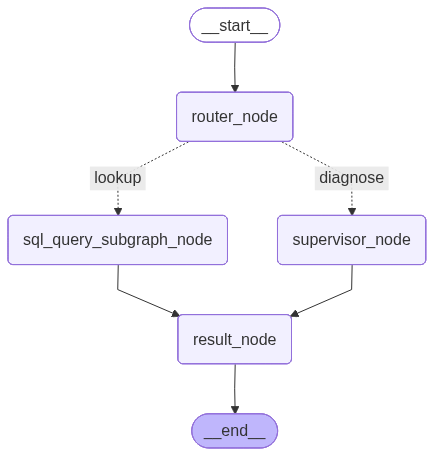

In [8]:
from functools import lru_cache
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

from domain.states.supervisor.diagnose_graph_state import WMState
from agents.nodes.query_enrich_node import router_node
from agents.edges.router_intent_edge import router_intent_edge
from agents.nodes.supervisor_node import WarehouseSupervisorNode
from agents.nodes.result_node import result_node
from agents.nodes.sql_lookup_subgraph_node import sql_query_subgraph_node
from IPython.display import display, Image

supervisor_node = WarehouseSupervisorNode()
@lru_cache(maxsize=1)
def _application_graph():
    builder = StateGraph(WMState)

    builder.add_node("router_node", router_node)
    builder.add_node("sql_query_subgraph_node", sql_query_subgraph_node)
    builder.add_node("supervisor_node", supervisor_node)
    builder.add_node("result_node", result_node)

    builder.add_edge(START, "router_node")

    builder.add_conditional_edges(
        "router_node",
        router_intent_edge,
        {
            "lookup": "sql_query_subgraph_node",
            "diagnose": "supervisor_node",
        },
    )

    builder.add_edge("sql_query_subgraph_node", "result_node")
    builder.add_edge("supervisor_node", "result_node")
    builder.add_edge("result_node", END)

    return builder

checkpointer = InMemorySaver()
graph = _application_graph().compile(checkpointer)
display(Image(graph.get_graph().draw_mermaid_png()))



In [1]:
from agents.nodes.query_enrich_node import query_enrich_node
from domain.states.supervisor.diagnose_graph_state import WMState
query_enrich_node(
    WMState(description="Why is P07283 not received and sku004 npt picked", session_id="example", ticket_number="INC",
                   user_id="rahul")
)

{'description': 'Investigate why Purchase Order (PO) P07283 has not been confirmed as received in the WMS — check Advanced Shipment Notice (ASN) status, dock records, and Goods Receipt Note (GRN). Simultaneously investigate why SKU004 has not been picked for its assigned Sales Order — check wave allocation, pick task generation, and inventory availability at the designated pick locations.',
 'routing_decision': ['inbound', 'outbound']}